# Medical Insurance Cost Analysis
## Spring 2026 Data Science Project

### Names:
- Thirunavukkarasu Sethuraman
- Sasidharan Vaithiyanathan
- Alex Yang

### Contributions

A: Project idea - The entire group as a whole (Thirunavukkarasu Sethuraman, Sasidharan Vaithiyanathan, and Alex Yang) selected this project idea.

B: Dataset Curation and Preprocessing - Thirunavukkarasu Sethuraman completed this section mostly, along with some help from Alex Yang and Sasidharan Vaithiyanathan for cleaning up/revising.

C: Data Exploration and Summary Statistics - Thirunavukkarasu Sethuraman selected and performed each hypothesis test, created conclusions based off of the results of those test, and created plots to show results.

D: ML Algorithm Design/Development - Thirunavukkarasu Sethuraman designed the first ML algorithm (linear regression) for the first question. Sasidharan Vaithiyanathan designed the second ML algorithm for the second question. Alex Yang developed the third ML algorithm for the third question.

E: ML Algorithm Training and Test Data Analysis - Thirunavukkarasu Sethuraman trained and performed the analysis for the first question. Sasidharan Vaithiyanathan trained and analyzed the model on test data for the second question. Alex Yang trained the random forest classifer and analyzed it's capabilties.

F: Visualization, Result Analysis, Conclusion - Alex Yang worked on the visualization for each of the three questions. Thirunavukkarasu Sethuraman and Sasidharan Vaithiyanathan worked on the result analysis(interpretation). Thirunavukkarasu Sethuraman worked on the final conclusion.

G: Final Tutorial Report Creation - The entire group worked on creating the final tutorial report.


# 2. Introduction

Healthcare costs in the United States can vary dramatically depending on a variety of personal and lifestyle factors. Insurance companies often use information such as age, smoking habits, body mass index (BMI), number of children, and geographic region to estimate risk and determine insurance premiums. Understanding which variables have the strongest effect on insurance charges is important because it can help individuals better understand healthcare pricing and identify behaviors that may increase medical expenses.

In this project, we analyze a medical insurance dataset to answer the following questions:

1. How does an individual's insurance charges change based on the various traits of the individual?
2. Are there hidden subgroups within smokers and non-smokers that reveal more nuanced cost patterns beyond smoking status alone?
3. Is it possible to categorize individuals into different insurance charge groups (low, medium, high) based on their characteristics?

To answer these questions, we use a combination of statistical hypothesis testing, exploratory data analysis, and machine learning regression models. Through these analyses, we aim to better understand the relationship between personal health characteristics and medical insurance pricing.

# 3. Data Curation

### Imports

The dataset used in this project is the “Medical Cost Personal Dataset” from Kaggle.

#### Citation
Abdel-Ghany, M. (2025). Medical Insurance Cost Dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset

We begin by loading the dataset using pandas and inspecting the first few rows to understand its structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains the following columns:
- age: age of the individual
- sex: gender
- bmi: body mass index
- children: number of dependents
- smoker: smoking status (yes/no)
- region: residential region
- charges: medical insurance cost

### Initial Data Inspection

Before performing any analysis, we check for missing values and verify that all data types are appropriate.

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

The dataset contains no missing values, meaning no imputation or row removal is required. This ensures that all observations can be used directly in analysis and modeling.

We can also check if there are any duplicate entries within the dataframe. If so, we can clean up the table by removing those entries.

In [4]:
print(f'Number of Duplicate Entries: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Number of Duplicate Entries (After Cleaning): {df.duplicated().sum()}')

Number of Duplicate Entries: 1
Number of Duplicate Entries (After Cleaning): 0


### Basic Data Characteristics

We next examine summary statistics to understand the distribution of numerical variables such as age, BMI, and insurance charges.

In [5]:
print(f'Dimension of the Table: {df.shape}\n') ## row by columns
print(f'Features: {df.columns}\n') ## names of columns/features
print(f'Feature Types: {df.dtypes}\n') ## datatypes of the features
print(f'Summary of Statistics of the Dataset: {df.describe()}\n') ## summary statistics

Dimension of the Table: (1337, 7)

Features: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Feature Types: age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Summary of Statistics of the Dataset:                age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010



# 4. Exploratory Data Analysis (EDA)

### Data Exploration: Part 1

For the first hypothesis test, we decided to test whether or not insurance charges varied significantly across different geographic regions. In order to identify the relationship between the two variables we decided to choose an ANOVA test since we were comparing the mean insurance charges across 3+ groups. Each group was a particular region: northwest, northeast, southwest, southeast.

Here the null hypothesis is that there is no statistical difference in mean insurance charges between the regions, and the alternative hypothesis is that there is a statistical difference in mean insurance charges between at least one pair of regions.

1) Hypothesis Testing: ANOVA test (3+ groups) (Region vs. Insurance Charges)

In [6]:
nw = df[df["region"] == "northwest"]["charges"]
ne = df[df["region"] == "northeast"]["charges"]
sw = df[df["region"] == "southwest"]["charges"]
se = df[df["region"] == "southeast"]["charges"]

f_statistic, p_value = stats.f_oneway(nw, ne, sw, se) ## ANOVA test
print(f'f_statistic: {f_statistic}, p_value: {p_value}')

f_statistic: 2.926139903662777, p_value: 0.03276288025444947


Given the output of the ANOVA test, the returned p-value was approximately 0.03 which is less than 0.05. Thus, we can reject the null hypothesis and conclude that there is a statistically significant difference in insurance charges across regions.

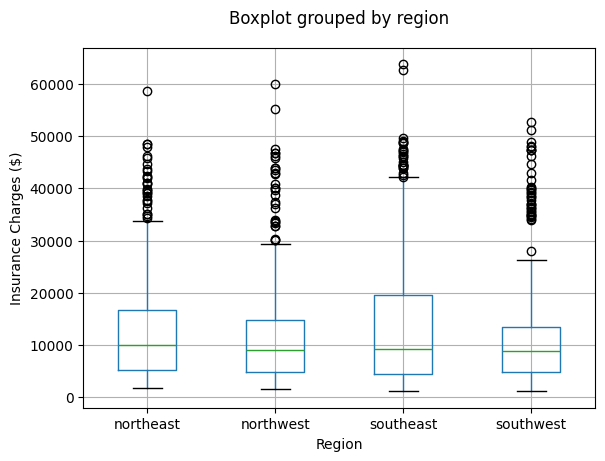

In [7]:
bp = df.boxplot(column="charges", by="region")
bp.get_figure().gca().set_title("")

plt.xlabel("Region")
plt.ylabel("Insurance Charges ($)")

plt.show()

We then decided to represent this data in a boxplot since it is great at highlighting the distribution of insurance charges across the different geographical regions. Now, while the p-value indicates that there is a statistically significant difference between the two variables, the boxplot distributions considerably overlap one another. The boxplot corresponding to the southeast region displays a high spread of data (variability), demonstrating that this region contributes heavily to the statistical significance. However, since there is high overlap amongst the boxplots, it is likely there are other factors that significantly affect insurance charges.

### Data Exploration 2

For the second hypothesis test, we decided to analyze whether or not there was a statistical relationship between whether or not an individual was a smoker and their corresponding BMI. A Chi-Square test was chosen to examine the association between two categorical variables since we wanted to determine the relationship between the two and see if the final results are as expected or not.

The null hypothesis is that there is no statistical difference between BMI and the smoking status of an individual, and the alternative hypothesis is that there is a statistical difference between BMI and the smoking status of an individual.

2. Chi-Square Test (Smoker Status vs. BMI)

In [8]:
# Contingency Table between smoker and bmi fields
df['bmi_groups'] = pd.cut(df['bmi'], bins=[15, 20, 25, 30, 35, 40, 45, 50, 55], labels=["15-20", "20-25", "25-30", "30-35", "35-40", "40-45", "45-50", "50-55"])
contingency_table = pd.crosstab(df['bmi_groups'], df['smoker'])
contingency_table

smoker,no,yes
bmi_groups,,
15-20,32,9
20-25,160,46
25-30,311,75
30-35,315,73
35-40,175,50
40-45,55,16
45-50,13,4
50-55,2,1


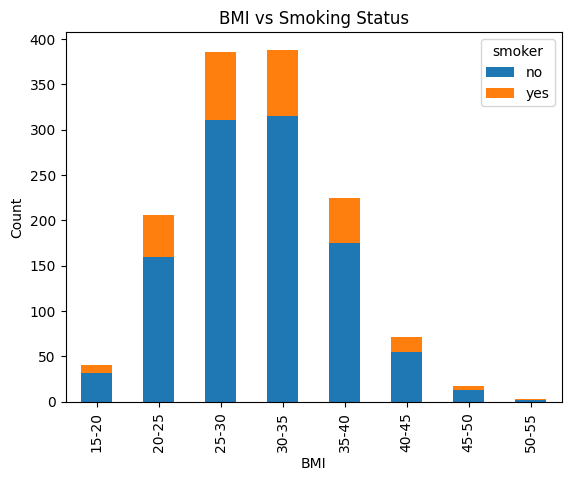

In [9]:
contingency_table.plot(kind='bar', stacked=True)
plt.title("BMI vs Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

In [10]:
_, p, _, _ = stats.chi2_contingency(contingency_table)
print(f'P-Value: {p}')

P-Value: 0.933488860056868


The outputted p-value by the test was approximately 0.93, which is greater than 0.05. Thus, we fail to reject the null hypothesis and conclude that there is no statistical relationship between BMI and smoking status.

### Data Exploration: Part 3

For the final hypothesis test, we decided to analyze whether or not an individual is a smoker had an effect on their insurance charges. We chose to apply a Mann-Whitney U test, which is great for this scenario since we are comparing differences between two independent groups (smokers vs. non-smokers) when the dependent variable (insurance charges) is continuous but not normally distributed. 

Here the null hypothesis is that there is no statistical difference between the smoking status and the insurance charges of an individual, and the alternative hypothesis is that there is a statistical difference between the smoking status and the insurance charges of an individual.

3. Mann-Whitney U Test (Smoker Status vs. Charges)

In [11]:
smoker = df[df['smoker'] == 'yes']['charges']
non_smoker = df[df['smoker'] == 'no']['charges']

_, p = stats.mannwhitneyu(non_smoker, smoker)
print(f'P-Value: {p}')

P-Value: 5.74701188239214e-130


The Mann-Whitney U test returned a p-value of approximately $5.27 \times 10^{-130}$ and $5.27 \times 10^{-130} << 0.05$. Consequently, it is fair to reject the null hypothesis and conclude that there is highly significant statistical difference in insurance charges between those who smoke and those who do not.

We then decided to represent this data in a boxplot since boxplots are able to display the data as a distribution and the overall spread of insurance charges across both groups.

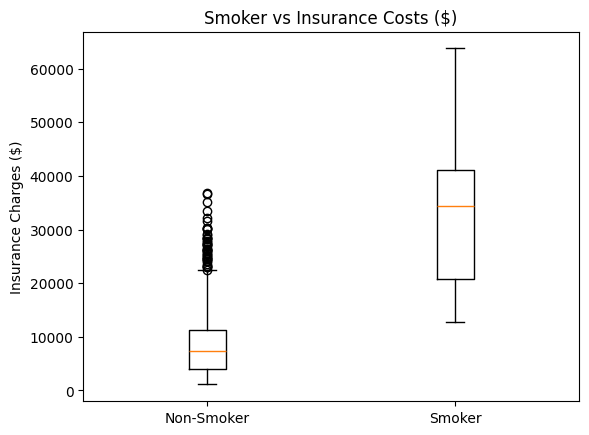

In [12]:
plt.boxplot([non_smoker, smoker], tick_labels=['Non-Smoker', 'Smoker'])
plt.title('Smoker vs Insurance Costs ($)')
plt.ylabel('Insurance Charges ($)')
plt.show()

The boxplots are quite different from one another since the mean insurance charge for an individual who does not smoke is a little less than \$10,000, meanwhile the mean insurance cost for a smoker is around \$35,000. There also exists a large spread of smokers compared to non-smokers which is indicated by their quartiles (edges) being farther apart than the mean. Therefore, it is fair to say that the binary value of whether or not an individual is a smoker is a strong relationship to use for future predictions.

# 5. Primary Analysis

### Question 1: How does an individual's insurance charges change based on the various traits of the individual?

Let's begin by analyzing the data and how various characteristics have an influence on an individual's insurance costs. The remainder of this section will focus on utilizing a linear regression model to predict an individual's insurance charges.

We can begin by importing the necessary packages.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

In [14]:
df.dtypes

age              int64
sex             object
bmi            float64
children         int64
smoker          object
region          object
charges        float64
bmi_groups    category
dtype: object

Going through the different datatypes of the features we can tell that there are some non-numerical features that need to be addressed/modified before proceeding with the training phase. This is because linear regression cannot handle objects and any object fields must be converted using some form of encoding. For this problem, we decided to perform one-hot encoding on the three categorical variables (sex, smoker, and region).

In [15]:
numerical_df = pd.get_dummies(df.drop(columns=['bmi_groups']), columns=['sex', 'region', 'smoker'])
numerical_df

,age,bmi,children,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,True,False,False,False,False,True,False,True
1,18,33.770,1,1725.55230,False,True,False,False,True,False,True,False
2,28,33.000,3,4449.46200,False,True,False,False,True,False,True,False
3,33,22.705,0,21984.47061,False,True,False,True,False,False,True,False
4,32,28.880,0,3866.85520,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,False,True,False,False,True,False
1334,18,31.920,0,2205.98080,True,False,True,False,False,False,True,False
1335,18,36.850,0,1629.83350,True,False,False,False,True,False,True,False
1336,21,25.800,0,2007.94500,True,False,False,False,False,True,True,False


### Training the Model

In [16]:
X = numerical_df.drop('charges', axis=1)
y = numerical_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error (MSE): 35478020.67523558
R^2 Score: 0.8069287081198013


A Mean Squared Error (MSE) is roughly 35,478,020 and taking the square root of this value will give is the average deviation from the mean is \$5,956. The $R^2$ value is roughly 0.81 which means the model explains about 81% percent of the variance in insurance changes. This is a good fit since the value is quite close to 1.

We were curious on which features contributed the most to the overall insurance cost, so we obtained the feature coefficients which are basically the weights attached to each feature. 

Higher feature coefficient = Higher Importance and Lower feature coefficient = Lower Importance

In [17]:
feature_coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(feature_coef.sort_values('Coefficient', ascending=False))

             Feature   Coefficient
10        smoker_yes  11538.882296
2           children    533.009989
5   region_northeast    472.455206
1                bmi    318.701441
0                age    248.210720
6   region_northwest     80.693751
3         sex_female     50.771027
4           sex_male    -50.771027
8   region_southwest   -186.684546
7   region_southeast   -366.464410
9          smoker_no -11538.882296


This shows that if an individual is a smoker, number of children they have, and the northeast region have the strongest weights. Hence, the largest impact on insurance charges.

### Question 2: Are there hidden subgroups within smokers and non-smokers that reveal more nuanced cost patterns beyond smoking status alone?

From our EDA we already know that smoking status has a strong effect on insurance charges. However, we want to explore whether there are further subgroups within smokers and non-smokers that explain additional variation in costs. We decided use K-Means Clustering separately on the smoker and non-smoker groups to see if subgroups can be found based on health characteristics like age and BMI.

We can begin by importing the necessary packages.

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Before applying K-Means, we need to scale the features since K-Means is sensitive to the scale of the data. Features with larger ranges would otherwise dominate the clustering.

In [19]:
scaler = StandardScaler()

smoker_df = numerical_df[numerical_df['smoker_yes'] == 1].copy()
non_smoker_df = numerical_df[numerical_df['smoker_no'] == 1].copy()

cluster_features = ['age', 'bmi', 'children', 'charges']

smoker_scaled = scaler.fit_transform(smoker_df[cluster_features])
non_smoker_scaled = scaler.fit_transform(non_smoker_df[cluster_features])

To determine the best number of clusters we used the elbow method, which plots the inertia for different values of k. The optimal k is where the inertia starts to level off.

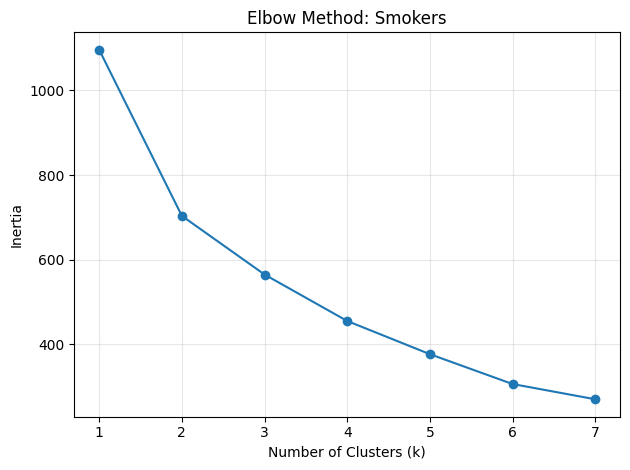

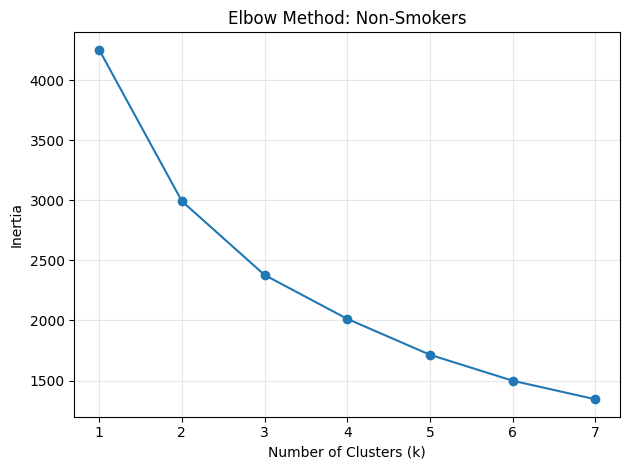

In [20]:
for label, data in [('Smokers', smoker_scaled), ('Non-Smokers', non_smoker_scaled)]:
    inertia = []
    for k in range(1, 8):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        inertia.append(km.inertia_)

    plt.plot(range(1, 8), inertia, marker='o')
    plt.title(f'Elbow Method: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Training the Model

In [21]:
smoker_df['cluster'] = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(smoker_scaled)
non_smoker_df['cluster'] = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(non_smoker_scaled)

print("Smoker Subgroups:")
print(smoker_df.groupby('cluster')[['age', 'bmi', 'children', 'charges']].mean())

print("\nNon-Smoker Subgroups:")
print(non_smoker_df.groupby('cluster')[['age', 'bmi', 'children', 'charges']].mean())

Smoker Subgroups:
               age        bmi  children       charges
cluster                                              
0        39.027397  35.443459  1.089041  41621.518818
1        37.929688  25.307578  1.140625  21132.982612

Non-Smoker Subgroups:
               age        bmi  children       charges
cluster                                              
0        28.107547  29.711717  0.967925   4154.343373
1        50.637899  31.586698  1.213884  12702.851629


Looking at the elbow plots, it drops the most from k=1 to k=2 for both smokers and non-smokers, so we decided to go with k=2 for both groups.

For the smoker subgroups, the two clusters are mostly separated by BMI since both groups have similar average ages of around 38-39. Cluster 0 has smokers with higher BMI and pays around \$41,622 on average, while Cluster 1 has smokers with lower BMI and pays around \$21,133 on average. This suggests that for smokers, having a high BMI on top of smoking can roughly double your insurance costs.

For the nonsmoker subgroups, the two clusters are mostly separated by age since both groups have similar average BMI values. Cluster 0 contains younger non-smokers with average charges of around \$4,154, while Cluster 1 contains older non-smokers with average charges of around \$12,703.

Overall, the clustering shows that smoking status alone does not tell the whole story when it comes to insurance costs. Within smokers, BMI seems to be the bigger factor, while within non-smokers, age plays a larger role. This lines up well with what we found in the EDA and linear regression sections, where age and BMI were both identified as important predictors.


### Question 3: Is it possible to categorize individuals into different insurance charge groups?

For the final question, we attempt to classify individuals into insurance charge groups based on their characteristics. We define three groups: Low for charges under \$10,000, Medium for charges between \$10,000 and \$30,000, and High for charges above \$30,000. Since this is a multi-class classification problem, we decided to use a random forest classifier, which handles non-linear relationships and mixed feature types well. Additionally, it tends to overfit less than a traditional decision tree.

Before training, we apply binning to the charges column into the three groups defined above.

In [22]:
from sklearn.ensemble import RandomForestClassifier

numerical_df['charge_group'] = pd.cut(
    numerical_df['charges'],
    bins=[0, 10000, 30000, float('inf')],
    labels=['Low', 'Medium', 'High']
)
numerical_df.dtypes

age                    int64
bmi                  float64
children               int64
charges              float64
sex_female              bool
sex_male                bool
region_northeast        bool
region_northwest        bool
region_southeast        bool
region_southwest        bool
smoker_no               bool
smoker_yes              bool
charge_group        category
dtype: object

### Training the Model

In [23]:
X_cg = numerical_df.drop(columns=['charges', 'charge_group'])
y_cg = numerical_df['charge_group']

X_train_cg, X_test_cg, y_train_cg, y_test_cg = train_test_split(X_cg, y_cg, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_cg, y_train_cg)

y_pred_cg = rf_model.predict(X_test_cg)

accuracy_cg = accuracy_score(y_test_cg, y_pred_cg)
print(f'Accuracy: {accuracy_cg}')
print(classification_report(y_test_cg, y_pred_cg, target_names=['Low', 'Medium', 'High']))

feature_imp_cg = pd.DataFrame({'Feature': X_cg.columns,'Importance': rf_model.feature_importances_})
print(feature_imp_cg.sort_values('Importance', ascending=False))

Accuracy: 0.914179104477612
              precision    recall  f1-score   support

         Low       1.00      0.90      0.95        42
      Medium       0.91      0.96      0.93       142
        High       0.88      0.85      0.86        84

    accuracy                           0.91       268
   macro avg       0.93      0.90      0.92       268
weighted avg       0.92      0.91      0.91       268

             Feature  Importance
0                age    0.422301
1                bmi    0.219088
9          smoker_no    0.144179
10        smoker_yes    0.115184
2           children    0.051953
6   region_northwest    0.009155
3         sex_female    0.007770
5   region_northeast    0.007768
7   region_southeast    0.007708
8   region_southwest    0.007683
4           sex_male    0.007210


The Random Forest Classifier achieved an accuracy of 91.4%, meaning the model was able to correctly classify individuals into their insurance charge group the vast majority of the time. Looking at the classification report, the model performs best on the Low and Medium charge groups with f1-scores of 0.95 and 0.93 respectively, and slightly lower on the High charge group with an f1-score of 0.86.

Looking at the feature importances, age is by far the most important feature with an importance score of 0.42, followed by BMI at 0.22 and smoking status at roughly 0.26 combined. This makes intuitive sense since older individuals and those with higher BMIs tend to have higher medical costs. Region and sex had very little impact on the classification, which is consistent with our EDA findings where regional differences in charges were statistically significant but had considerable overlap.

Overall, the model suggests that it is possible to categorize individuals into insurance charge groups based on their characteristics, with age, BMI, and smoking status being the most useful predictors.

# 6. Visualization

### Visualization: How does an individual's insurance charges change based on the various traits of the individual? (Question 1)

In order to visualize the results of the linear regression we decided to utilize a scatter plot and a best-fitted line layered on top. Additionally, we decided to incorporate another chart to show the importance of each feature.

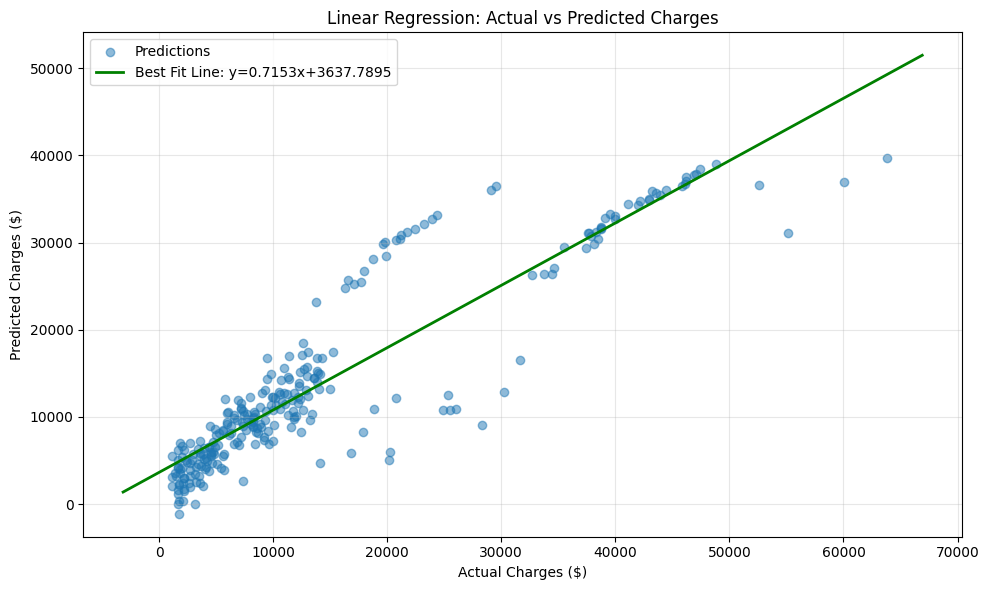

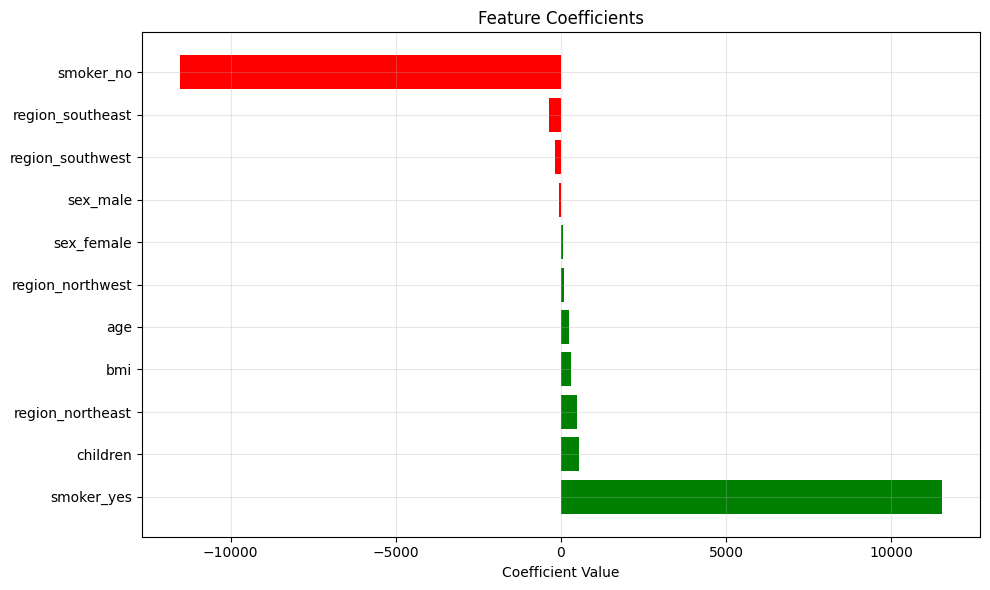

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')

boundaries = [np.min([plt.xlim(), plt.ylim()]), np.max([plt.xlim(), plt.ylim()])]

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
x_line = np.array(boundaries)
plt.plot(x_line, p(x_line), 'g-', lw=2, label=f'Best Fit Line: y={z[0]:.4f}x+{z[1]:.4f}')

plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Linear Regression: Actual vs Predicted Charges')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
feature_coef = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_}).sort_values('Coefficient', ascending=False)

colors = ['green' if x > 0 else 'red' for x in feature_coef['Coefficient']]
plt.barh(feature_coef['Feature'], feature_coef['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation

The scanner plot shows actual vs predicted charges with an ideal prediction line (solid green). The bar chart shows the most important features by their coefficients. The green bars indicate positive correlation between the features and the weights, and red indicates negative.

### Visualization: Does demographic and health characteristics affect smoking status? (Question 2)

In order to visualize the results of the K-Means clustering we decided to use scatter plots of age vs BMI colored by cluster for both smokers and non-smokers. Additionally, we decided to incorporate bar charts to show the average insurance charges per cluster for each group.

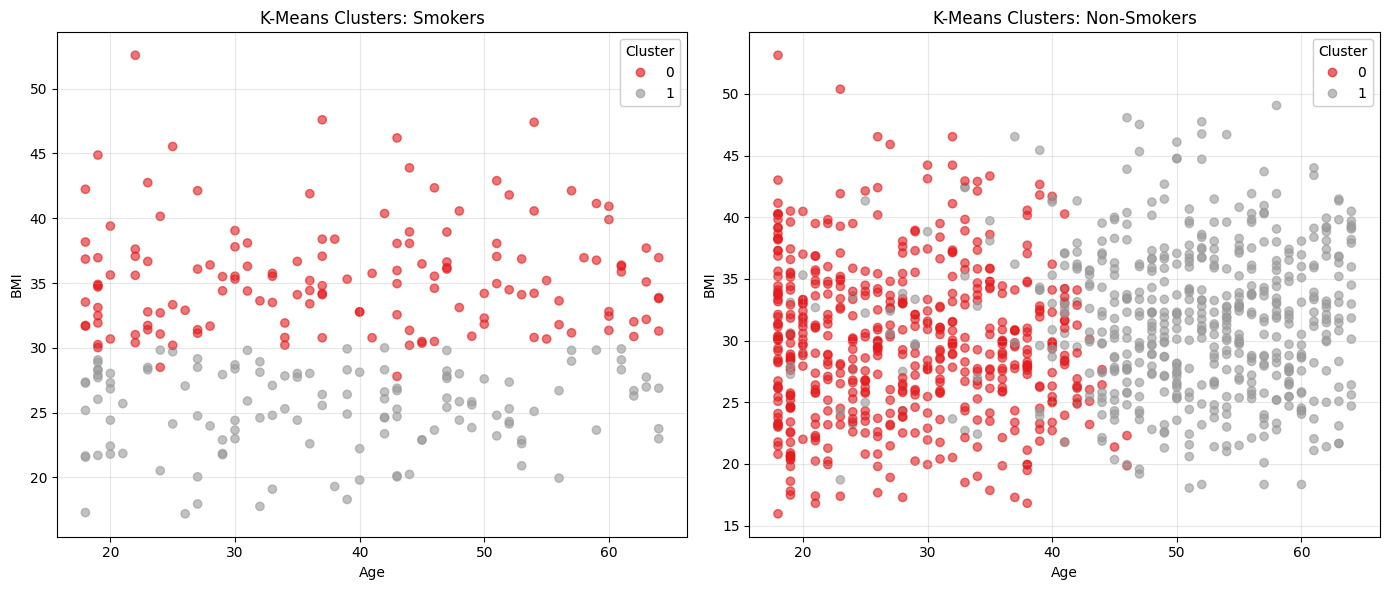

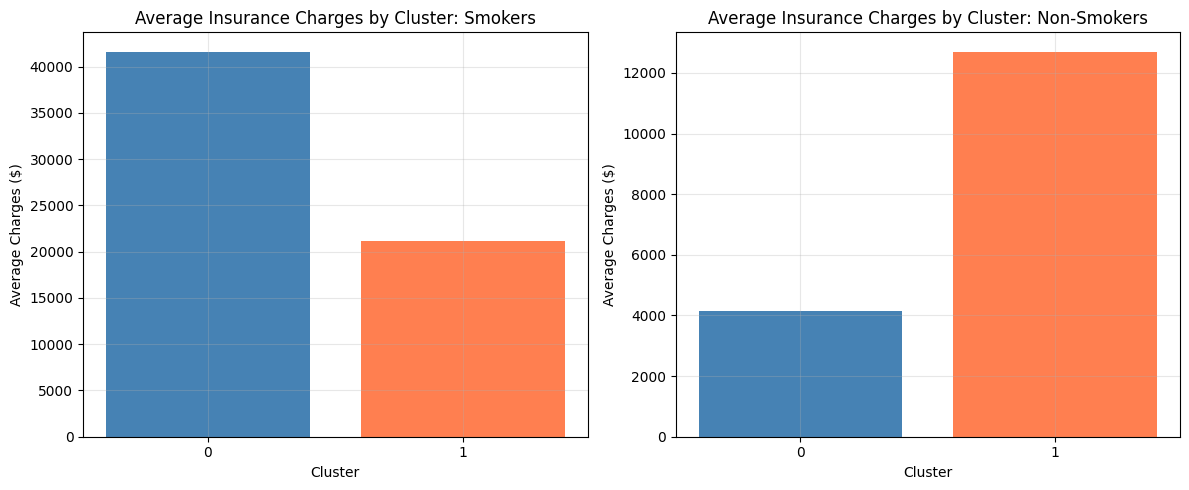

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_group, title in zip(axes, [smoker_df, non_smoker_df], ['Smokers', 'Non-Smokers']):
    scatter = ax.scatter(df_group['age'], df_group['bmi'], c=df_group['cluster'], cmap='Set1', alpha=0.6)
    ax.set_xlabel('Age')
    ax.set_ylabel('BMI')
    ax.set_title(f'K-Means Clusters: {title}')
    legend = ax.legend(*scatter.legend_elements(), title='Cluster')
    ax.add_artist(legend)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df_group, title in zip(axes, [smoker_df, non_smoker_df], ['Smokers', 'Non-Smokers']):
    cluster_means = df_group.groupby('cluster')['charges'].mean()
    ax.bar(cluster_means.index.astype(str), cluster_means.values, color=['steelblue', 'coral'])
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Average Charges ($)')
    ax.set_title(f'Average Insurance Charges by Cluster: {title}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plots show how individuals are grouped by age and BMI for smokers and non-smokers separately. For smokers, the two clusters are clearly separated along the BMI axis, with Cluster 0 sitting at higher BMI values and Cluster 1 at lower BMI values across all age groups. For non-smokers, the clusters are more mixed along the BMI axis but separated along the age axis, with Cluster 0 containing mostly younger individuals and Cluster 1 containing mostly older individuals.

The bar charts confirm the cost differences between clusters. For smokers, Cluster 0 has average charges of around $41,622 while Cluster 1 has average charges of around $21,133, meaning high BMI smokers pay roughly twice as much. For non-smokers, Cluster 0 has average charges of around $4,154 while Cluster 1 has average charges of around $12,703, meaning older non-smokers pay roughly three times as much as younger non-smokers.

### Visualization: Is it possible to categorize individuals into different insurance charge groups? (Question 3)

We visualize the Random Forest Classifier's performance through a tree visualization, feature importance rankings, and classification metrics for predicting insurance charge groups.

We decided to visualize the random forest classifier's performance with the decision tree.

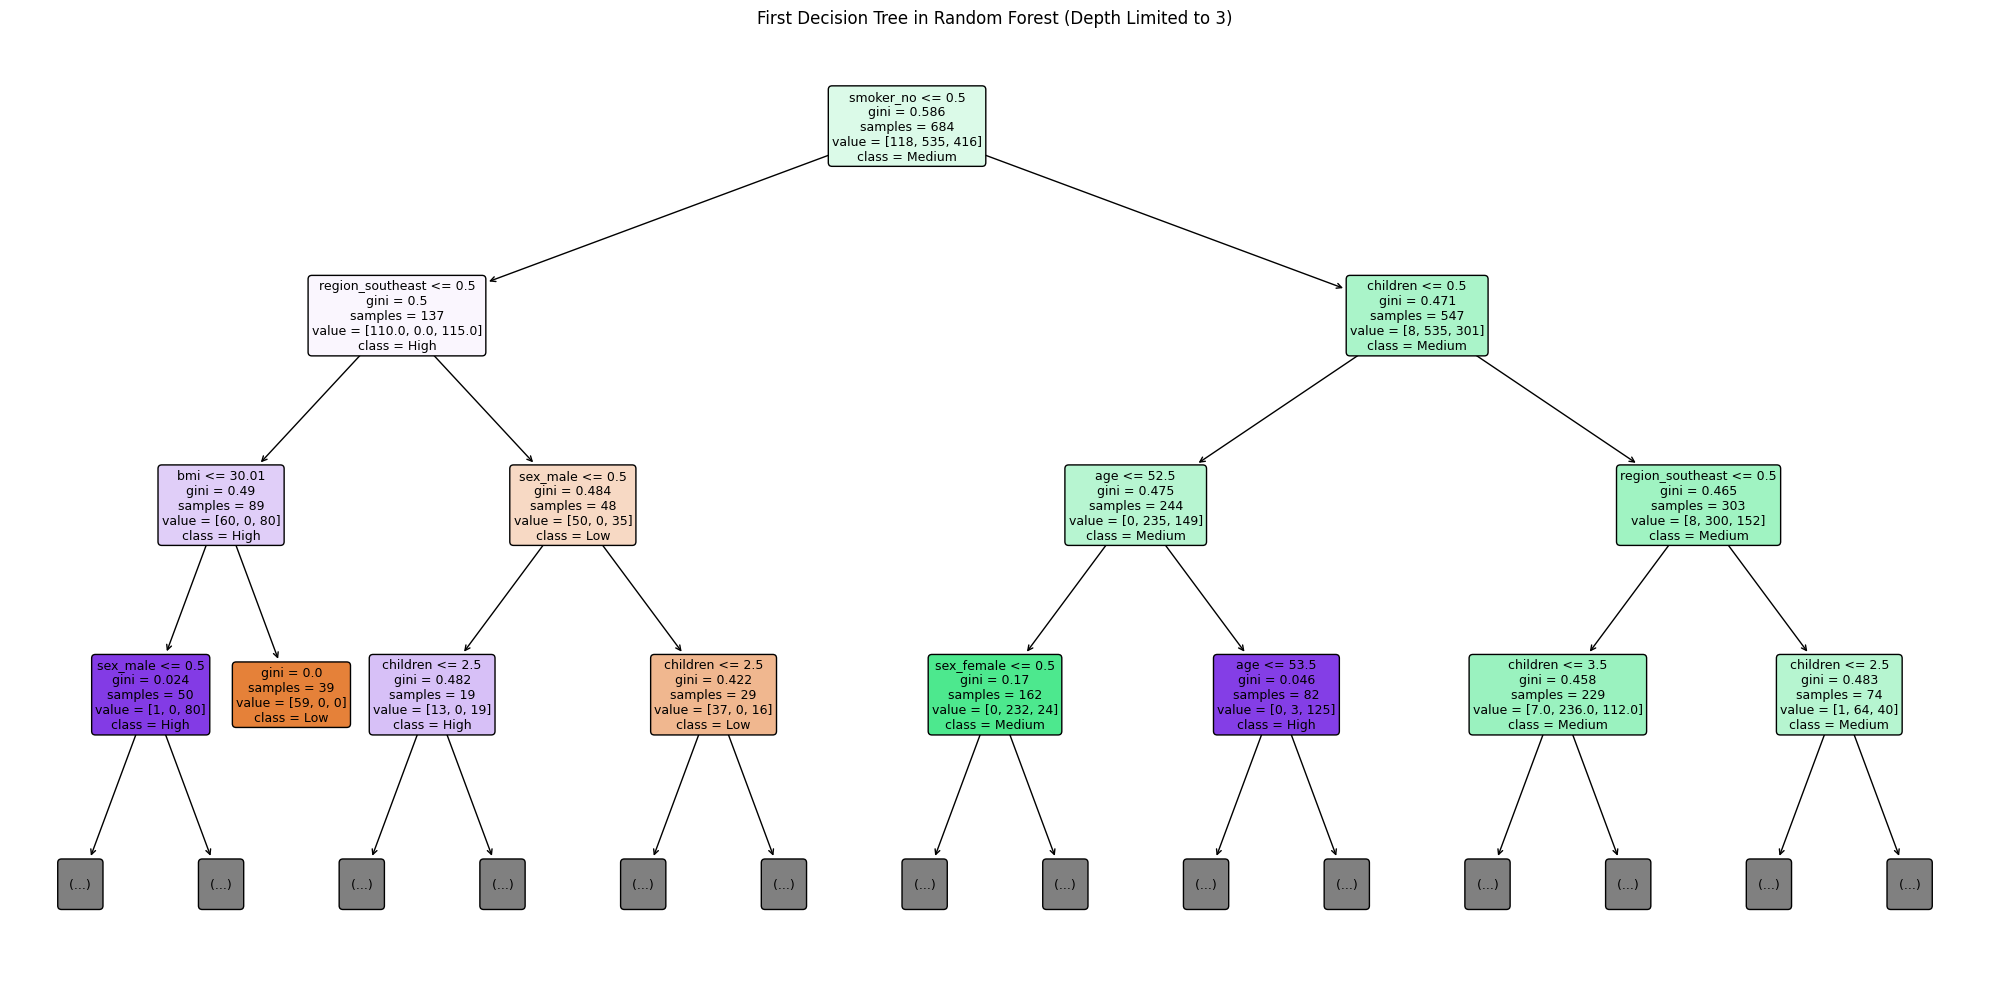

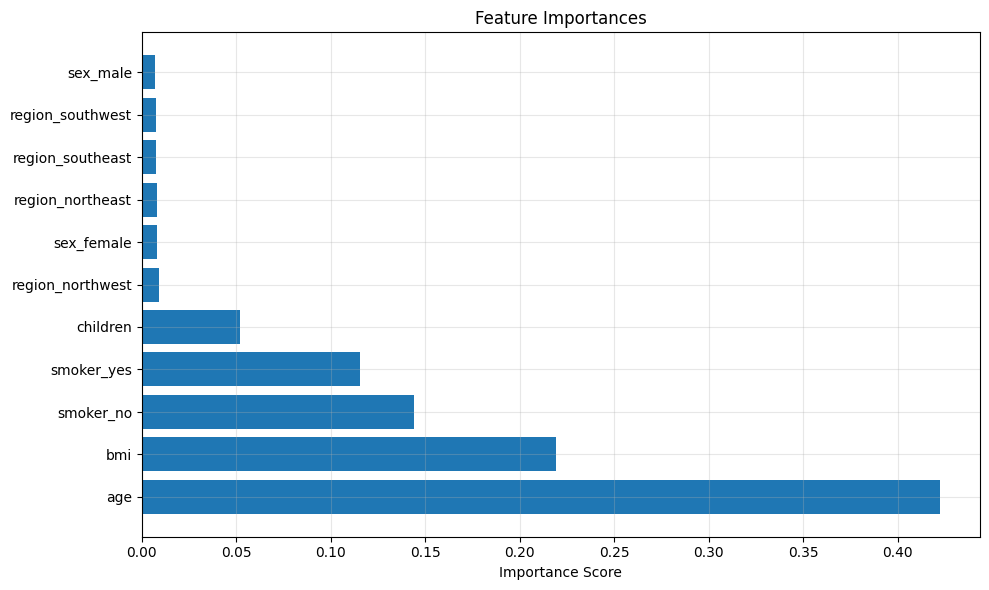

In [25]:
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(rf_model.estimators_[0], 
               feature_names=X_train_cg.columns,
               class_names=['Low', 'Medium', 'High'],
               filled=True,
               rounded=True,
               fontsize=9,
               max_depth=3)
plt.title('First Decision Tree in Random Forest (Depth Limited to 3)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
feature_imp_cg = pd.DataFrame({'Feature': X_train_cg.columns,'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False)

plt.barh(feature_imp_cg['Feature'], feature_imp_cg['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importances')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Interpretation

The first plot is a diagram of the first decision tree in the random forest classifier that was used. Unfortunately, the depth was limted to 3 since the entire tree wouldn't fit properly within a plot. The second plot demonstrates the feature importances for each of the features in terms of determining which group each individual belongs in. From this chart we can see that age has the highest importance, followed by bmi and smoking status.